In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../../../..").resolve()))

BLOCK_DIR = Path("..").resolve()  # -> block2_stress/

DATA_DIR      = str(BLOCK_DIR / "data/stress")
FORECAST_DIR  = str(BLOCK_DIR / "data/forecasts")
RESULTS_DIR   = str(BLOCK_DIR / "results/style")

MOIRAIE_CKPT = "/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last"
MOIRAIC_CKPT = "/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last"

DEVICE    = "cpu"
N_SAMPLES = 6
SEED      = 42

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from experiments.mech_interp.block2_stress import load_stress_dataset
from experiments.mech_interp.block2_stress.run_forecasts import load_forecasts
from experiments.mech_interp.block2_stress.metrics import forecast_spike_rate

## (Optional) Load models and regenerate forecasts

Skip this cell if cached forecasts already exist in `data/forecasts/`.

In [3]:
# from experiments.mech_interp.lib.utils import _load_module
# from experiments.mech_interp.block2_stress.run_forecasts import run_and_save_all
#
# run_and_save_all(
#     moiraie_ckpt=MOIRAIE_CKPT,
#     moiraic_ckpt=MOIRAIC_CKPT,
#     data_dir=DATA_DIR,
#     output_dir=FORECAST_DIR,
#     families=["family_c_intermittent", "family_c_rand_amp"],
#     device=DEVICE,
# )

## Plot helper

In [ ]:
ENC_COLOR = "tab:orange"
DEC_COLOR = "tab:blue"

CTX_LEN = 256
T       = 320
t_ctx   = np.arange(CTX_LEN)
t_fc    = np.arange(CTX_LEN, T)


def _panel_title(meta: dict, idx: int, family: str) -> str:
    period = int(meta["period_ts"][idx])
    if family == "family_c_intermittent":
        p = float(meta["p"][idx])
        return f"period={period}, p={p:.2f}"
    else:
        amp_var = float(meta["amp_var"][idx])
        return f"period={period}, amp_var={amp_var:.2f}"


def plot_style_grid(
    family: str,
    level_key: str,
    fixed_idxs: np.ndarray,
    enc_res: dict,
    dec_res: dict,
    series: np.ndarray,
    meta: dict,
    title: str,
    save_dir: str | None = None,
) -> plt.Figure:
    """
    2-row x N_SAMPLES grid. Row 0 = encoder (moiraie), row 1 = decoder (moiraic).
    Returns figure. Saves to save_dir/{family}/{level_key}.png if save_dir given.
    """
    n = len(fixed_idxs)
    fig, axes = plt.subplots(2, n, figsize=(n * 3, 4), squeeze=False)
    fig.suptitle(title, fontsize=10)

    rows = [
        (enc_res, ENC_COLOR, "encoder (moiraie)"),
        (dec_res, DEC_COLOR, "decoder (moiraic)"),
    ]

    for row_idx, (res, color, row_label) in enumerate(rows):
        fq = res["forecast_quantiles"]  # [n_total, 9, 64]
        for col, idx in enumerate(fixed_idxs):
            ax = axes[row_idx, col]

            ax.plot(t_ctx, series[idx, :CTX_LEN], color="grey", lw=0.8)
            ax.axvspan(CTX_LEN, T, color="orange", alpha=0.08)
            ax.plot(t_fc, series[idx, CTX_LEN:], color="black", lw=1.0, ls="--")
            ax.axvline(CTX_LEN, color="gray", lw=0.8, ls="--")

            ax.fill_between(t_fc, fq[idx, 0], fq[idx, 8], color=color, alpha=0.25)
            ax.plot(t_fc, fq[idx, 4], color=color, lw=1.2)

            ax.tick_params(labelsize=7)
            ax.set_xlim(0, T)
            ax.set_title(_panel_title(meta, idx, family), fontsize=8)

            if col == 0:
                ax.set_ylabel(row_label, fontsize=7)

    fig.tight_layout()

    if save_dir is not None:
        out = Path(save_dir) / family
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f"{level_key}.png", dpi=150, bbox_inches="tight")

    return fig

## Family C — Intermittent

fixed_idxs: [165 195 110 219 111  22]


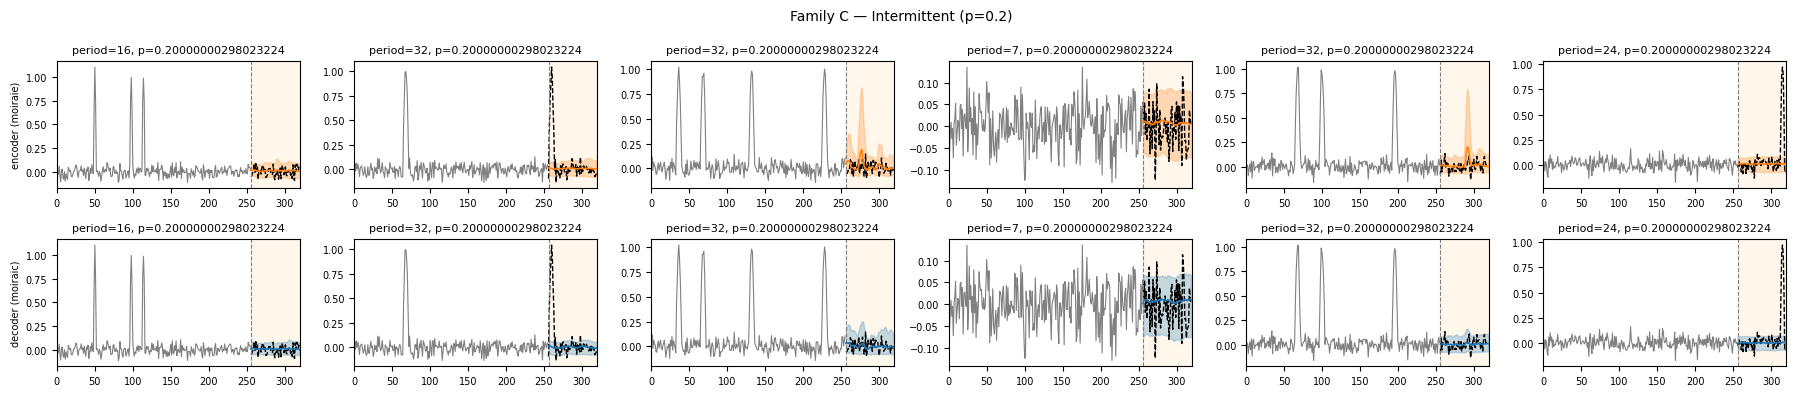

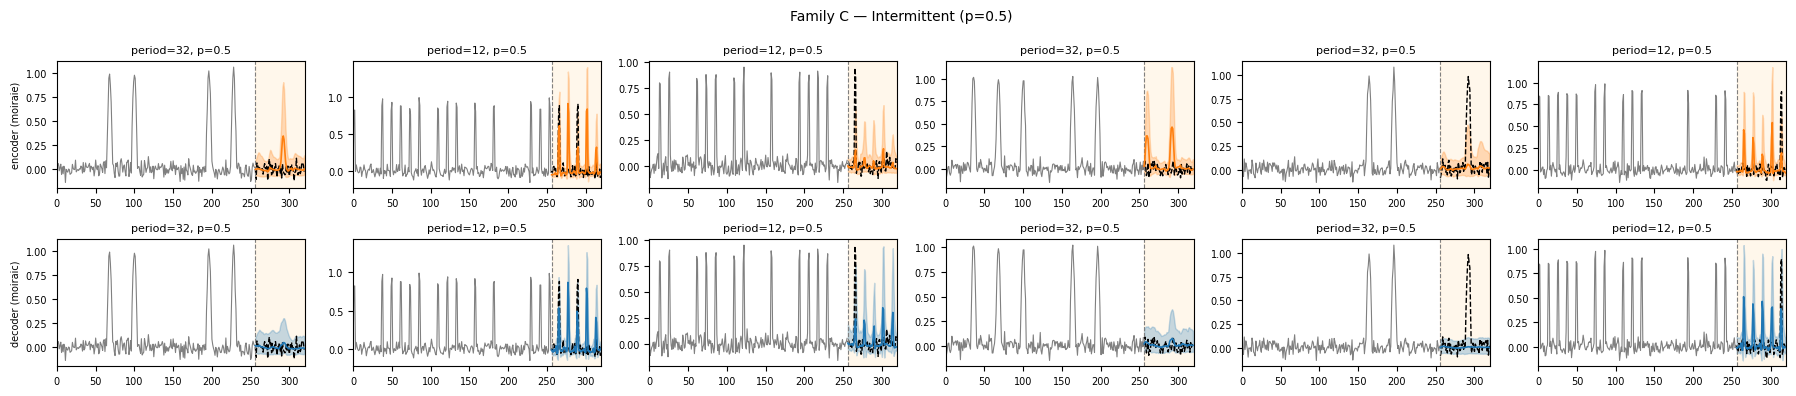

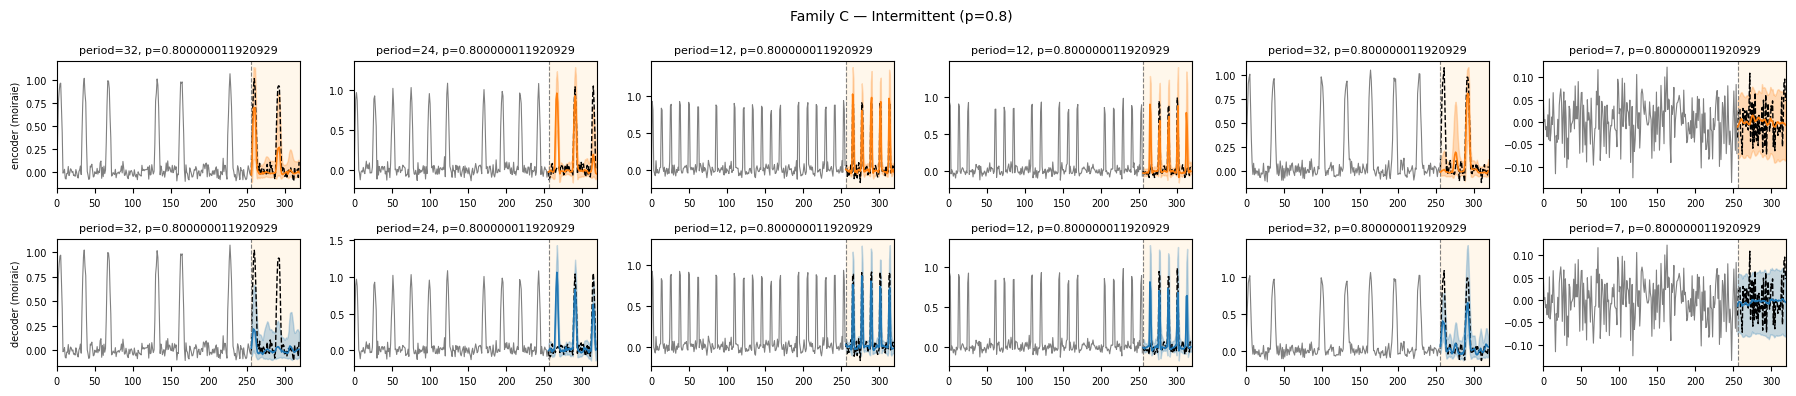

In [ ]:
family     = "family_c_intermittent"
level_keys = ["p_00", "p_01", "p_02"]
p_values   = [0.2, 0.5, 0.8]

rng = np.random.default_rng(SEED)
series0, _, _ = load_stress_dataset(DATA_DIR, family, level_keys[0])
fixed_idxs = rng.choice(len(series0), size=N_SAMPLES, replace=False)
print("fixed_idxs:", fixed_idxs)

for level_key, p in zip(level_keys, p_values):
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res = load_forecasts(FORECAST_DIR, "moiraie", family, level_key)
    dec_res = load_forecasts(FORECAST_DIR, "moiraic", family, level_key)

    assert enc_res["forecast_quantiles"].shape == (256, 9, 64), enc_res["forecast_quantiles"].shape
    assert dec_res["forecast_quantiles"].shape == (256, 9, 64), dec_res["forecast_quantiles"].shape

    fig = plot_style_grid(
        family=family,
        level_key=level_key,
        fixed_idxs=fixed_idxs,
        enc_res=enc_res,
        dec_res=dec_res,
        series=series,
        meta=meta,
        title=f"Family C — Intermittent (p={p:.2f})",
        save_dir=RESULTS_DIR,
    )
    plt.show()
    plt.close(fig)

## Family C — Rand-Amp

fixed_idxs: [165 195 110 219 111  22]


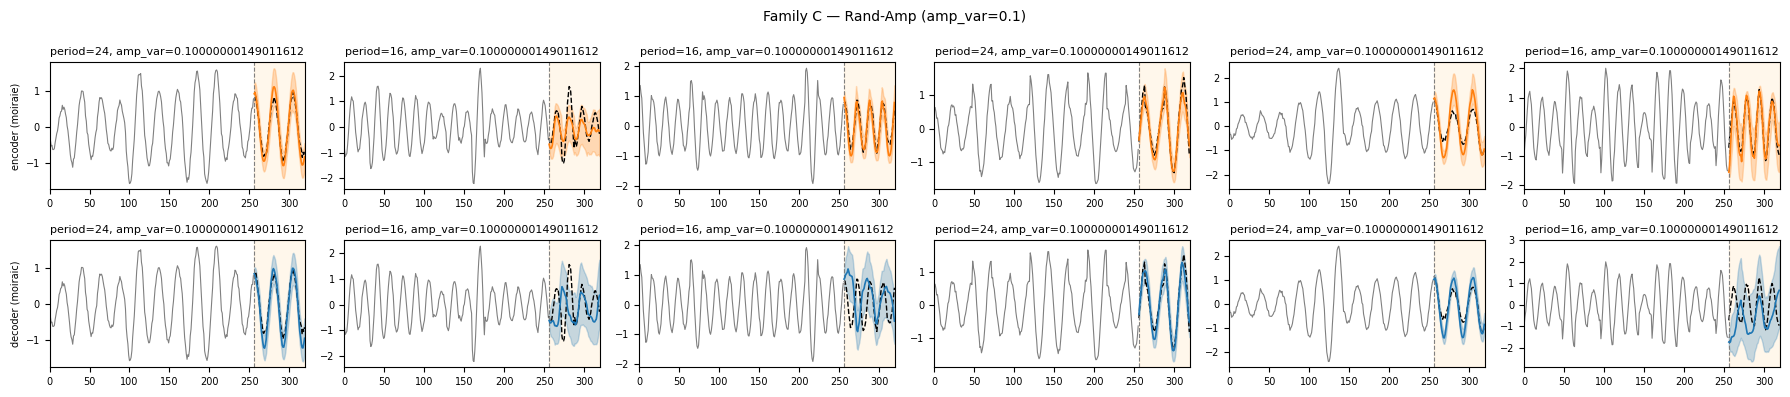

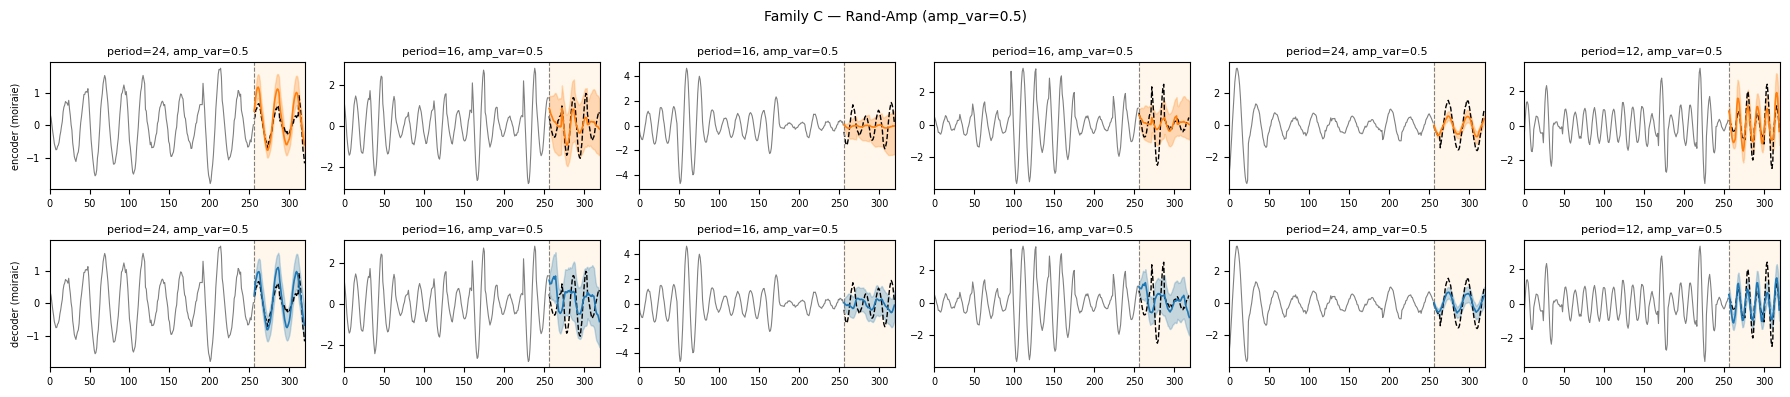

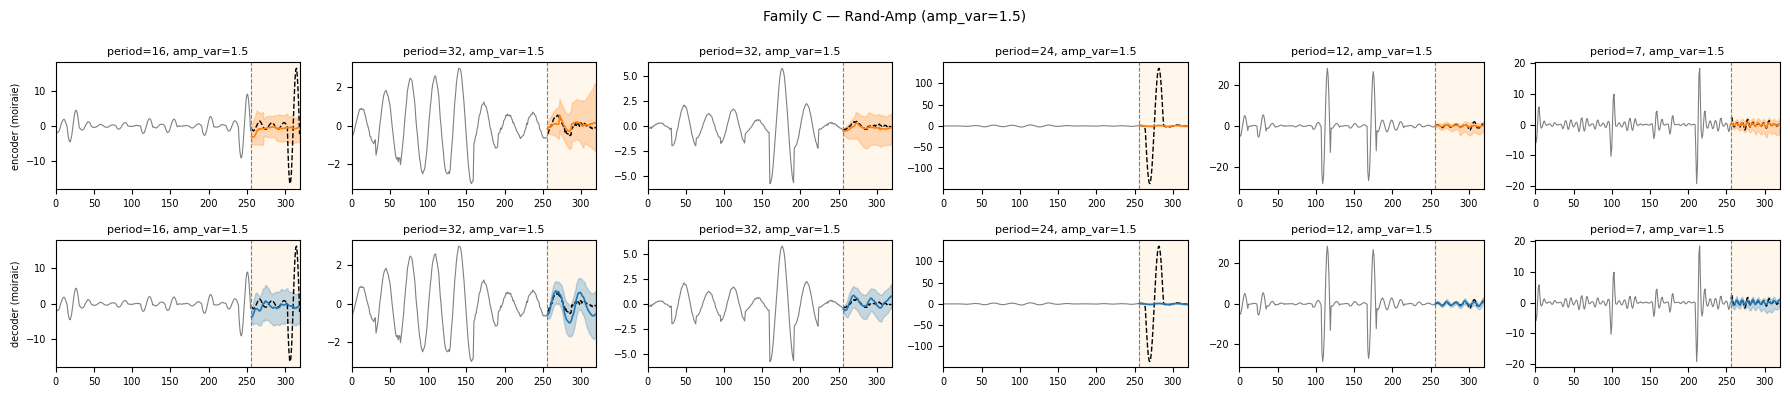

In [6]:
family     = "family_c_rand_amp"
level_keys = ["var_00", "var_01", "var_02"]
var_values = [0.1, 0.5, 1.5]

rng = np.random.default_rng(SEED)
series0, _, _ = load_stress_dataset(DATA_DIR, family, level_keys[0])
fixed_idxs = rng.choice(len(series0), size=N_SAMPLES, replace=False)
print("fixed_idxs:", fixed_idxs)

for level_key, amp_var in zip(level_keys, var_values):
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res = load_forecasts(FORECAST_DIR, "moiraie", family, level_key)
    dec_res = load_forecasts(FORECAST_DIR, "moiraic", family, level_key)

    assert enc_res["forecast_quantiles"].shape == (256, 9, 64), enc_res["forecast_quantiles"].shape
    assert dec_res["forecast_quantiles"].shape == (256, 9, 64), dec_res["forecast_quantiles"].shape

    fig = plot_style_grid(
        family=family,
        level_key=level_key,
        fixed_idxs=fixed_idxs,
        enc_res=enc_res,
        dec_res=dec_res,
        series=series,
        meta=meta,
        title=f"Family C — Rand-Amp (amp_var={amp_var})",
        save_dir=RESULTS_DIR,
    )
    plt.show()
    plt.close(fig)

## Spike rate bar chart — Family C Intermittent

For each p level, `forecast_spike_rate` divides the 64-step horizon into
floor(H/P) windows of length P and counts the fraction with a peak above 0.3.
A calibrated model should return a rate close to the true p.
Error bars show ±1 std across the 256 series.

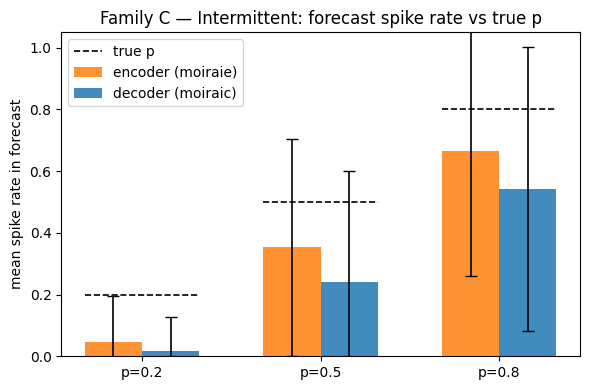

In [7]:
family     = "family_c_intermittent"
level_keys = ["p_00", "p_01", "p_02"]
p_values   = [0.2, 0.5, 0.8]

enc_means, enc_stds = [], []
dec_means, dec_stds = [], []

for level_key in level_keys:
    _, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res = load_forecasts(FORECAST_DIR, "moiraie", family, level_key)
    dec_res = load_forecasts(FORECAST_DIR, "moiraic", family, level_key)

    enc_median = enc_res["forecast_quantiles"][:, 4, :]  # [n, H]
    dec_median = dec_res["forecast_quantiles"][:, 4, :]  # [n, H]

    enc_rates = forecast_spike_rate(enc_median, meta)
    dec_rates = forecast_spike_rate(dec_median, meta)

    enc_means.append(enc_rates.mean())
    enc_stds.append(enc_rates.std())
    dec_means.append(dec_rates.mean())
    dec_stds.append(dec_rates.std())

x = np.arange(len(p_values))
width = 0.32

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(x - width / 2, enc_means, width, yerr=enc_stds,
       color=ENC_COLOR, alpha=0.85, label="encoder (moiraie)",
       capsize=4, error_kw={"lw": 1.2})
ax.bar(x + width / 2, dec_means, width, yerr=dec_stds,
       color=DEC_COLOR, alpha=0.85, label="decoder (moiraic)",
       capsize=4, error_kw={"lw": 1.2})

# Reference: true Bernoulli(p) rate
for xi, p in zip(x, p_values):
    ax.plot([xi - width, xi + width], [p, p],
            color="black", lw=1.2, ls="--")
ax.plot([], [], color="black", lw=1.2, ls="--", label="true p")

ax.set_xticks(x)
ax.set_xticklabels([f"p={p}" for p in p_values])
ax.set_ylabel("mean spike rate in forecast")
ax.set_ylim(0, 1.05)
ax.set_title("Family C — Intermittent: forecast spike rate vs true p")
ax.legend()
fig.tight_layout()

out = Path(RESULTS_DIR) / family
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "spike_rate_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Spike rate distribution — violin plot

Same data as the bar chart above but shows the full per-series distribution of spike rates rather than just mean ± std.

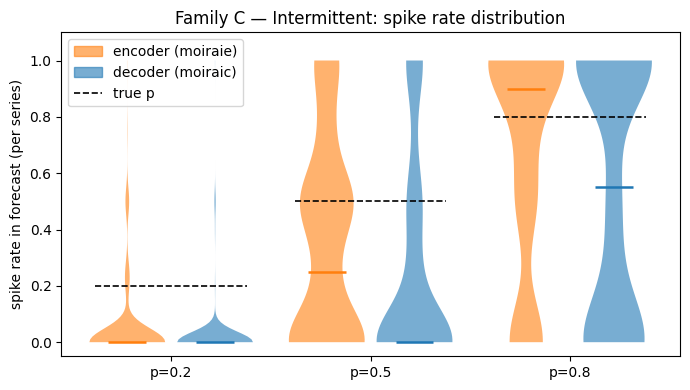

In [12]:
family     = "family_c_intermittent"
level_keys = ["p_00", "p_01", "p_02"]
p_values   = [0.2, 0.5, 0.8]

enc_all, dec_all = [], []

for level_key in level_keys:
    _, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res = load_forecasts(FORECAST_DIR, "moiraie", family, level_key)
    dec_res = load_forecasts(FORECAST_DIR, "moiraic", family, level_key)

    enc_median = enc_res["forecast_quantiles"][:, 4, :]
    dec_median = dec_res["forecast_quantiles"][:, 4, :]

    enc_all.append(forecast_spike_rate(enc_median, meta))
    dec_all.append(forecast_spike_rate(dec_median, meta))

x = np.arange(len(p_values))
offsets = [-0.22, 0.22]
colors  = [ENC_COLOR, DEC_COLOR]
labels  = ["encoder (moiraie)", "decoder (moiraic)"]
data_sets = [enc_all, dec_all]

fig, ax = plt.subplots(figsize=(7, 4))

for data, offset, color, label in zip(data_sets, offsets, colors, labels):
    positions = x + offset
    parts = ax.violinplot(data, positions=positions, widths=0.38,
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color(color)
    parts["cmedians"].set_linewidth(1.8)
    # legend proxy
    ax.fill_between([], [], color=color, alpha=0.6, label=label)

# Reference: true Bernoulli(p) rate
for xi, p in zip(x, p_values):
    ax.plot([xi - 0.38, xi + 0.38], [p, p],
            color="black", lw=1.2, ls="--")
ax.plot([], [], color="black", lw=1.2, ls="--", label="true p")

ax.set_xticks(x)
ax.set_xticklabels([f"p={p}" for p in p_values])
ax.set_ylabel("spike rate in forecast (per series)")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Family C — Intermittent: spike rate distribution")
ax.legend(loc="upper left")
fig.tight_layout()

out = Path(RESULTS_DIR) / family
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "spike_rate_violin.png", dpi=150, bbox_inches="tight")
plt.show()